In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np

In [ ]:
uploaded = files.upload()

Saving images.jpg to images.jpg


In [ ]:
img_path = next(iter(uploaded))
img = cv2.imread(img_path)

In [ ]:
if img is None:
  print("Error: Image not found or unable to read.")

In [ ]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [ ]:
resized = cv2.resize(img, (300, 300))

In [ ]:
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

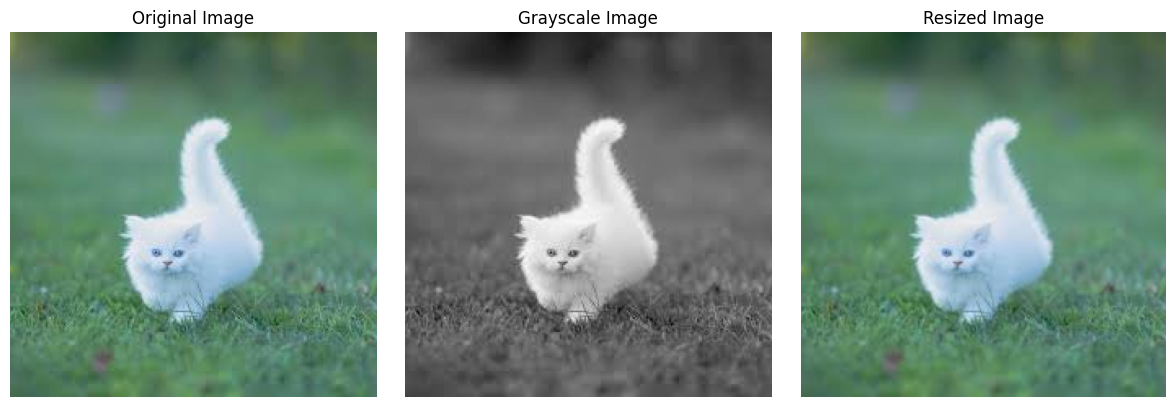

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title("Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title("Resized Image")
plt.imshow(resized_rgb)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
cv2.imwrite('gray_sample.jpg', gray)
cv2.imwrite('resized_sample.jpg', resized)

True

In [ ]:
print("Images saved as 'gray_sample.jpg' and 'resized_sample.jpg'")

Images saved as 'gray_sample.jpg' and 'resized_sample.jpg'


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
# Upload original image
uploaded = files.upload()

Saving goat.jpg to goat.jpg


In [ ]:
img_path = next(iter(uploaded))
img = cv2.imread(img_path)

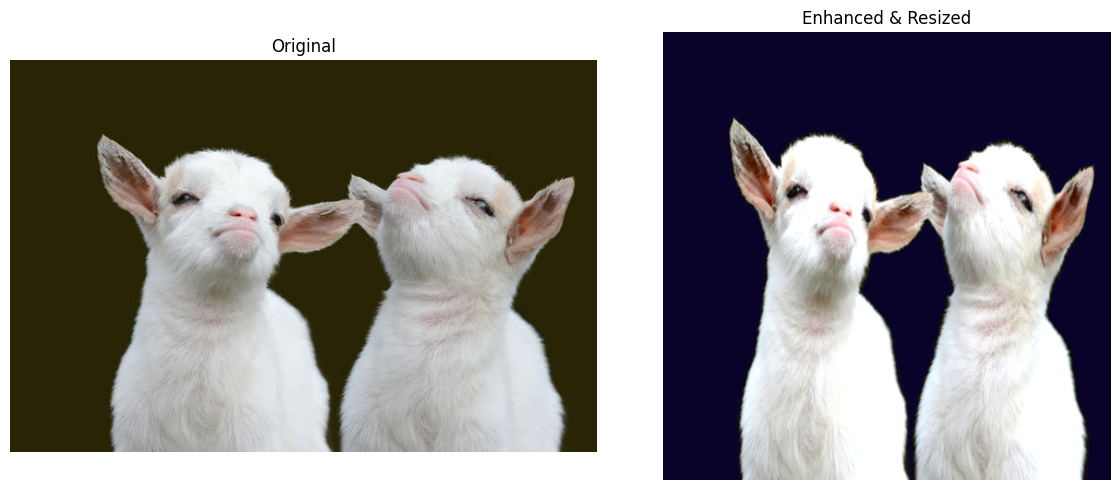

In [ ]:
def auto_brightness_contrast(image, clip_hist_percent=25):
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  hist = cv2.calcHist([gray],[0],None,[256],[0,256]).flatten()
  acc = np.cumsum(hist)
  clip = clip_hist_percent * (acc[-1] / 100.0) / 2.0
  min_gray = np.searchsorted(acc, clip)
  max_gray = np.searchsorted(acc, acc[-1] - clip)
  alpha = 255 / (max_gray - min_gray + 1e-5)
  beta = -min_gray * alpha
  return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

enhanced = auto_brightness_contrast(img)
resized = cv2.resize(enhanced, (1080, 1080))
# Show before and after
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original")
ax[1].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
ax[1].set_title("Enhanced & Resized")
for a in ax: a.axis('off')
plt.tight_layout()
plt.show()

In [2]:
import cv2
from google.colab import files
import os

In [3]:
print("Upload your CCTV image (e.g., .jpg, .png)...")
uploaded = files.upload()

Upload your CCTV image (e.g., .jpg, .png)...


Saving fog.jpg to fog.jpg


In [4]:
input_image_path = list(uploaded.keys())[0]

In [5]:
color_image = cv2.imread(input_image_path)

In [6]:
if color_image is None:
  print("Error: Unable to read the image.")
else:
# Step 5: Convert the image to grayscale
  gray_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)
# Step 6: Save the grayscale image with a new filename
  output_image_path = 'cam_001_gray.jpg'
  cv2.imwrite(output_image_path, gray_image)
# Step 7: Download the saved grayscale image
  print(f"Grayscale image saved as: {output_image_path}")
  files.download(output_image_path)

Grayscale image saved as: cam_001_gray.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
S

In [ ]:
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

In [ ]:
uploaded = files.upload()

Saving 333.jpg to 333.jpg
Saving hitler.jpg to hitler (2).jpg


In [ ]:
paths = list(uploaded.keys())

MSE: 107.13
SSIM: 0.4123


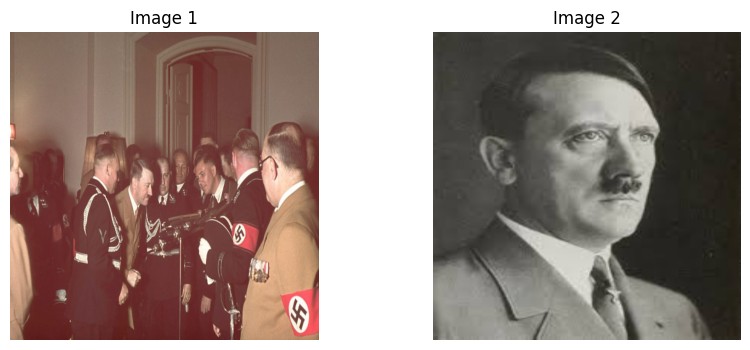

In [ ]:
# Read and resize
img1 = cv2.imread(paths[0])
img2 = cv2.imread(paths[1])
img1 = cv2.resize(img1, (500, 500))
img2 = cv2.resize(img2, (500, 500))
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
# MSE and SSIM
mse = np.mean((gray1 - gray2) ** 2)
ssim_score, _ = ssim(gray1, gray2, full=True)
print(f"MSE: {mse:.2f}")
print(f"SSIM: {ssim_score:.4f}")
# Show both images
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
ax[0].set_title("Image 1")
ax[1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax[1].set_title("Image 2")
for a in ax: a.axis('off')
plt.show()

Upload an image to detect red objects...


Saving download.jpg to download.jpg


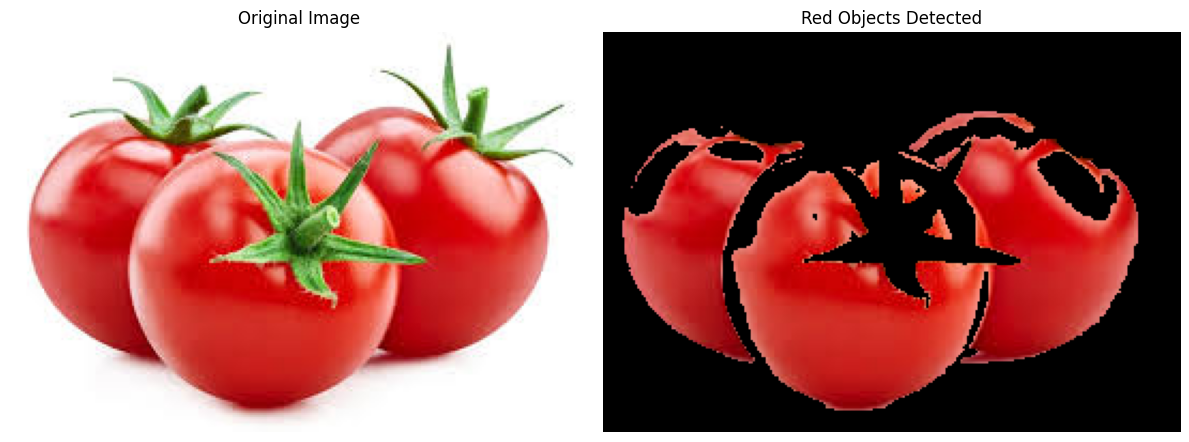

In [ ]:
import cv2
import numpy as np
from google.colab import files
from matplotlib import pyplot as plt

print("Upload an image to detect red objects...")
uploaded = files.upload()
input_image_path = list(uploaded.keys())[0]

image = cv2.imread(input_image_path)
if image is None:
  print("Error: Couldn't read the image.")
else:
  hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

  lower_red1 = np.array([0, 120, 70])
  upper_red1 = np.array([10, 255, 255])
  lower_red2 = np.array([170, 120, 70])
  upper_red2 = np.array([180, 255, 255])

  mask1 = cv2.inRange(hsv_image, lower_red1, upper_red1)
  mask2 = cv2.inRange(hsv_image, lower_red2, upper_red2)
  red_mask = mask1 + mask2

  red_detected = cv2.bitwise_and(image, image, mask=red_mask)

  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  plt.title("Original Image")
  plt.axis('off')
  plt.subplot(1, 2, 2)
  plt.imshow(cv2.cvtColor(red_detected, cv2.COLOR_BGR2RGB))
  plt.title("Red Objects Detected")
  plt.axis('off')
  plt.tight_layout()
  plt.show()